# Lecture 1

In this lecture we started on decision making, we have discussed decision making `under risk` and `under ignorance`

The main difference is that `under ignorance` we just have the outcomes without specifiyng their probabilities, and for `under risk` we have the probabilities and we use expected outcomes to make decisions.

## Eval methods
There was discussed these 4 approaches to make decisions:
- Maximin
- Maximax
- Pesimist-Optimist
- Minimax Regret

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import seaborn as sns

# Example

Now consider the following problem:

You have $10,000 to invest and are considering three investment options.
The return on your investment depends on the economic conditions over the next year (which are uncertain).

  Decision Alternatives:
  1. Stocks (S) - Invest in a diversified stock portfolio
  2. Bonds (B) - Invest in government bonds
  3. Mixed (M) - Split 50/50 between stocks and bonds

  States of Nature (Economic Conditions):
  - Strong Economy - Market performs well
  - Stable Economy - Market performs moderately
  - Weak Economy - Market performs poorly

Payoff Table

 | Decision | Strong Economy | Stable Economy | Weak Economy |
  |----------|----------------|----------------|--------------|
  | Stocks   | +3,000         | +800           | -1,500       |
  | Bonds    | +500           | +600           | +400         |
  | Mixed    | +1,750         | +700           | -550         | 


In [3]:
pay = np.array([[3000, 800, -1500],
                [500, 600, 400],
                [1750, 700, -550]])

sp.Matrix(pay)

Matrix([
[3000, 800, -1500],
[ 500, 600,   400],
[1750, 700,  -550]])

## Under ignorance (no probabilities)

### Maximin

We need to maximize the worst possible outcome, in other words we expect the worst to happen (Pesimistic).

For that calculate the minimum outome for each action and find the maximum of this vector, then the result is the best action according to maximin

In [4]:
mins = np.min(pay, axis=1)

sp.Matrix(mins)

Matrix([
[-1500],
[  400],
[ -550]])

In [5]:
max_min = np.argmax(mins, axis=0)

max_min

np.int64(1)

Or shorter, this operattion looks like:

In [6]:
max_min = np.argmax(np.min(pay, axis=1), axis=0)

max_min

np.int64(1)

The result of agrmax is 1, so the optimal decision using the maximin onder ignorance is `Bonds`

### Maximax

The approach is identical, the only difference that we look for maximum outcome for each action instead of minimum, hence the resut is:

### Pessimism-Optimism appraoch

In such scenario we balance our preference towards using min or max with additional factor $\alpha$ called optimism index, such that $o \leq \alpha \leq 1$.

We look for a weighted max and min of the action using the following formula
$$
value = \alpha \cdot min + (1 - \alpha) \cdot max
$$

In [7]:
max_max = np.argmax(np.max(pay, axis=1), axis=0)

max_max

np.int64(0)

Where 0 represents `Stocks`

In [8]:
alpha = 0.3

mins = np.min(pay, axis=1)
maxs = np.max(pay, axis=1)

weighted = alpha * maxs + (1-alpha) * mins

summary = sp.Matrix.hstack(sp.Matrix(mins), sp.Matrix(maxs), sp.Matrix(weighted))

summary

Matrix([
[-1500, 3000, -150.0],
[  400,  600,  460.0],
[ -550, 1750,  140.0]])

In [9]:
result = np.argmax(weighted, axis=0)

result

np.int64(1)

So with $\alpha = 0.3$ quite pessimistic scenraio the optimal decision is `Bonds` which is more conservative decision

We could experiment more by ploting how the decision changes with change of alpha

In [10]:
intervals = np.arange(0,1,0.05)

actions = []

for alpha in intervals:
    mins = np.min(pay, axis=1)
    maxs = np.max(pay, axis=1)

    weighted = alpha * maxs + (1-alpha) * mins

    result = np.argmax(weighted, axis=0)

    actions.append(result)

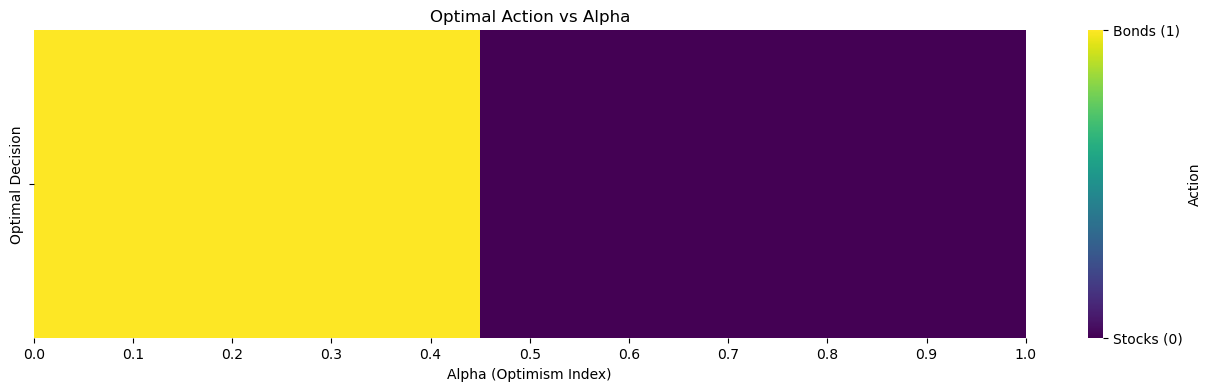

In [ ]:
plt.figure(figsize=(16,4))
# Reshape actions to 1 row
heatmap_data = np.array(actions).reshape(1, -1)

ax = sns.heatmap(heatmap_data, cmap='viridis',
                 cbar_kws={'label': 'Action',
                           'ticks': [0, 1, 2],
                           'format': '%.0f'})

# Customize colorbar to show action names
colorbar = ax.collections[0].colorbar
colorbar.set_ticklabels(['Stocks (0)', 'Bonds (1)', 'Mixed (2)'])
# Set x-axis to show alpha values
n_ticks = 11
tick_positions = np.linspace(0, len(intervals),
 n_ticks)
tick_labels = np.linspace(0, 1, n_ticks)
plt.xticks(tick_positions, [f'{x:.1f}' for x in
 tick_labels])
plt.xlabel('Alpha (Optimism Index)')
plt.ylabel('')
plt.yticks([0.5], ['Optimal Decision'])
plt.title('Optimal Action vs Alpha')
plt.show()

### Minimax Regret 

The regret is the difference between the bets outcome of given state and the obtained outcome of the dcision.

the goal is to take an action minimize the maximal regret

for that:

1. Find best outcome for each state
2. Compute regret matrix
3. apply minimax on regret matrix

In [30]:
best = np.max(pay, axis=0)
best

array([3000,  800,  400])

In [37]:
regret = -(pay - best)

sp.Matrix(regret)

Matrix([
[   0,   0, 1900],
[2500, 200,    0],
[1250, 100,  950]])

In [41]:
maxs = np.max(regret, axis=1)

action = np.argmin(maxs)

action

np.int64(2)

The minimax results in selecting `Mixed` approach, since it is in some sense inbetween the 2 other options, and the decision to go for mixed results prevents us from geting a lot of regreet for investing in stocks when market is bad, and regret for not making so much money, while investing in bonds, when the market performs well

## Decision Making under Risk

In this scenario we know the probabilities of getting to certain state, these might be used to make better decisions

Now assume the states are distibuted as follows:

|Strong | Stable | Week|
|-----|-----|-----------|
|0.4 | 0.3 | 0.3|

Then the expected outcome is just payoff weighted by the market probability

In [42]:
probabilities = np.array([0.4, 0.3, 0.3])

expected_outcomes = pay @ probabilities

expected_outcomes

array([990., 500., 745.])